# Applying ML Models for Financial Fraud Detection

In [ ]:
# Data & Analysis
import pandas as pd
import numpy as np
from sklearn.utils import resample

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,roc_curve , accuracy_score, precision_score, recall_score, f1_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset loading
import kagglehub
from kagglehub import KaggleDatasetAdapter




import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression


from scipy.stats import loguniform
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler , SMOTE

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV


## Load Data set

### Kaggle

In [ ]:


# Set the path to the file you'd like to load
file_path = "creditcard.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)



/tmp/ipython-input-2500229766.py:5: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


### local

In [ ]:
#df = pd.read_csv("creditcard.csv")

## Data Preprocessing

### Data Exploration

In [ ]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [ ]:
pd.options.display.max_columns = None

In [ ]:
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
print(df.shape)

(284807, 31)


In [ ]:
print("Number of rows: {} ".format(df.shape[0]))
print("Number of cluumns: {}".format(df.shape[1]))


Number of rows: 284807 
Number of cluumns: 31


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df = df.dropna()

array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

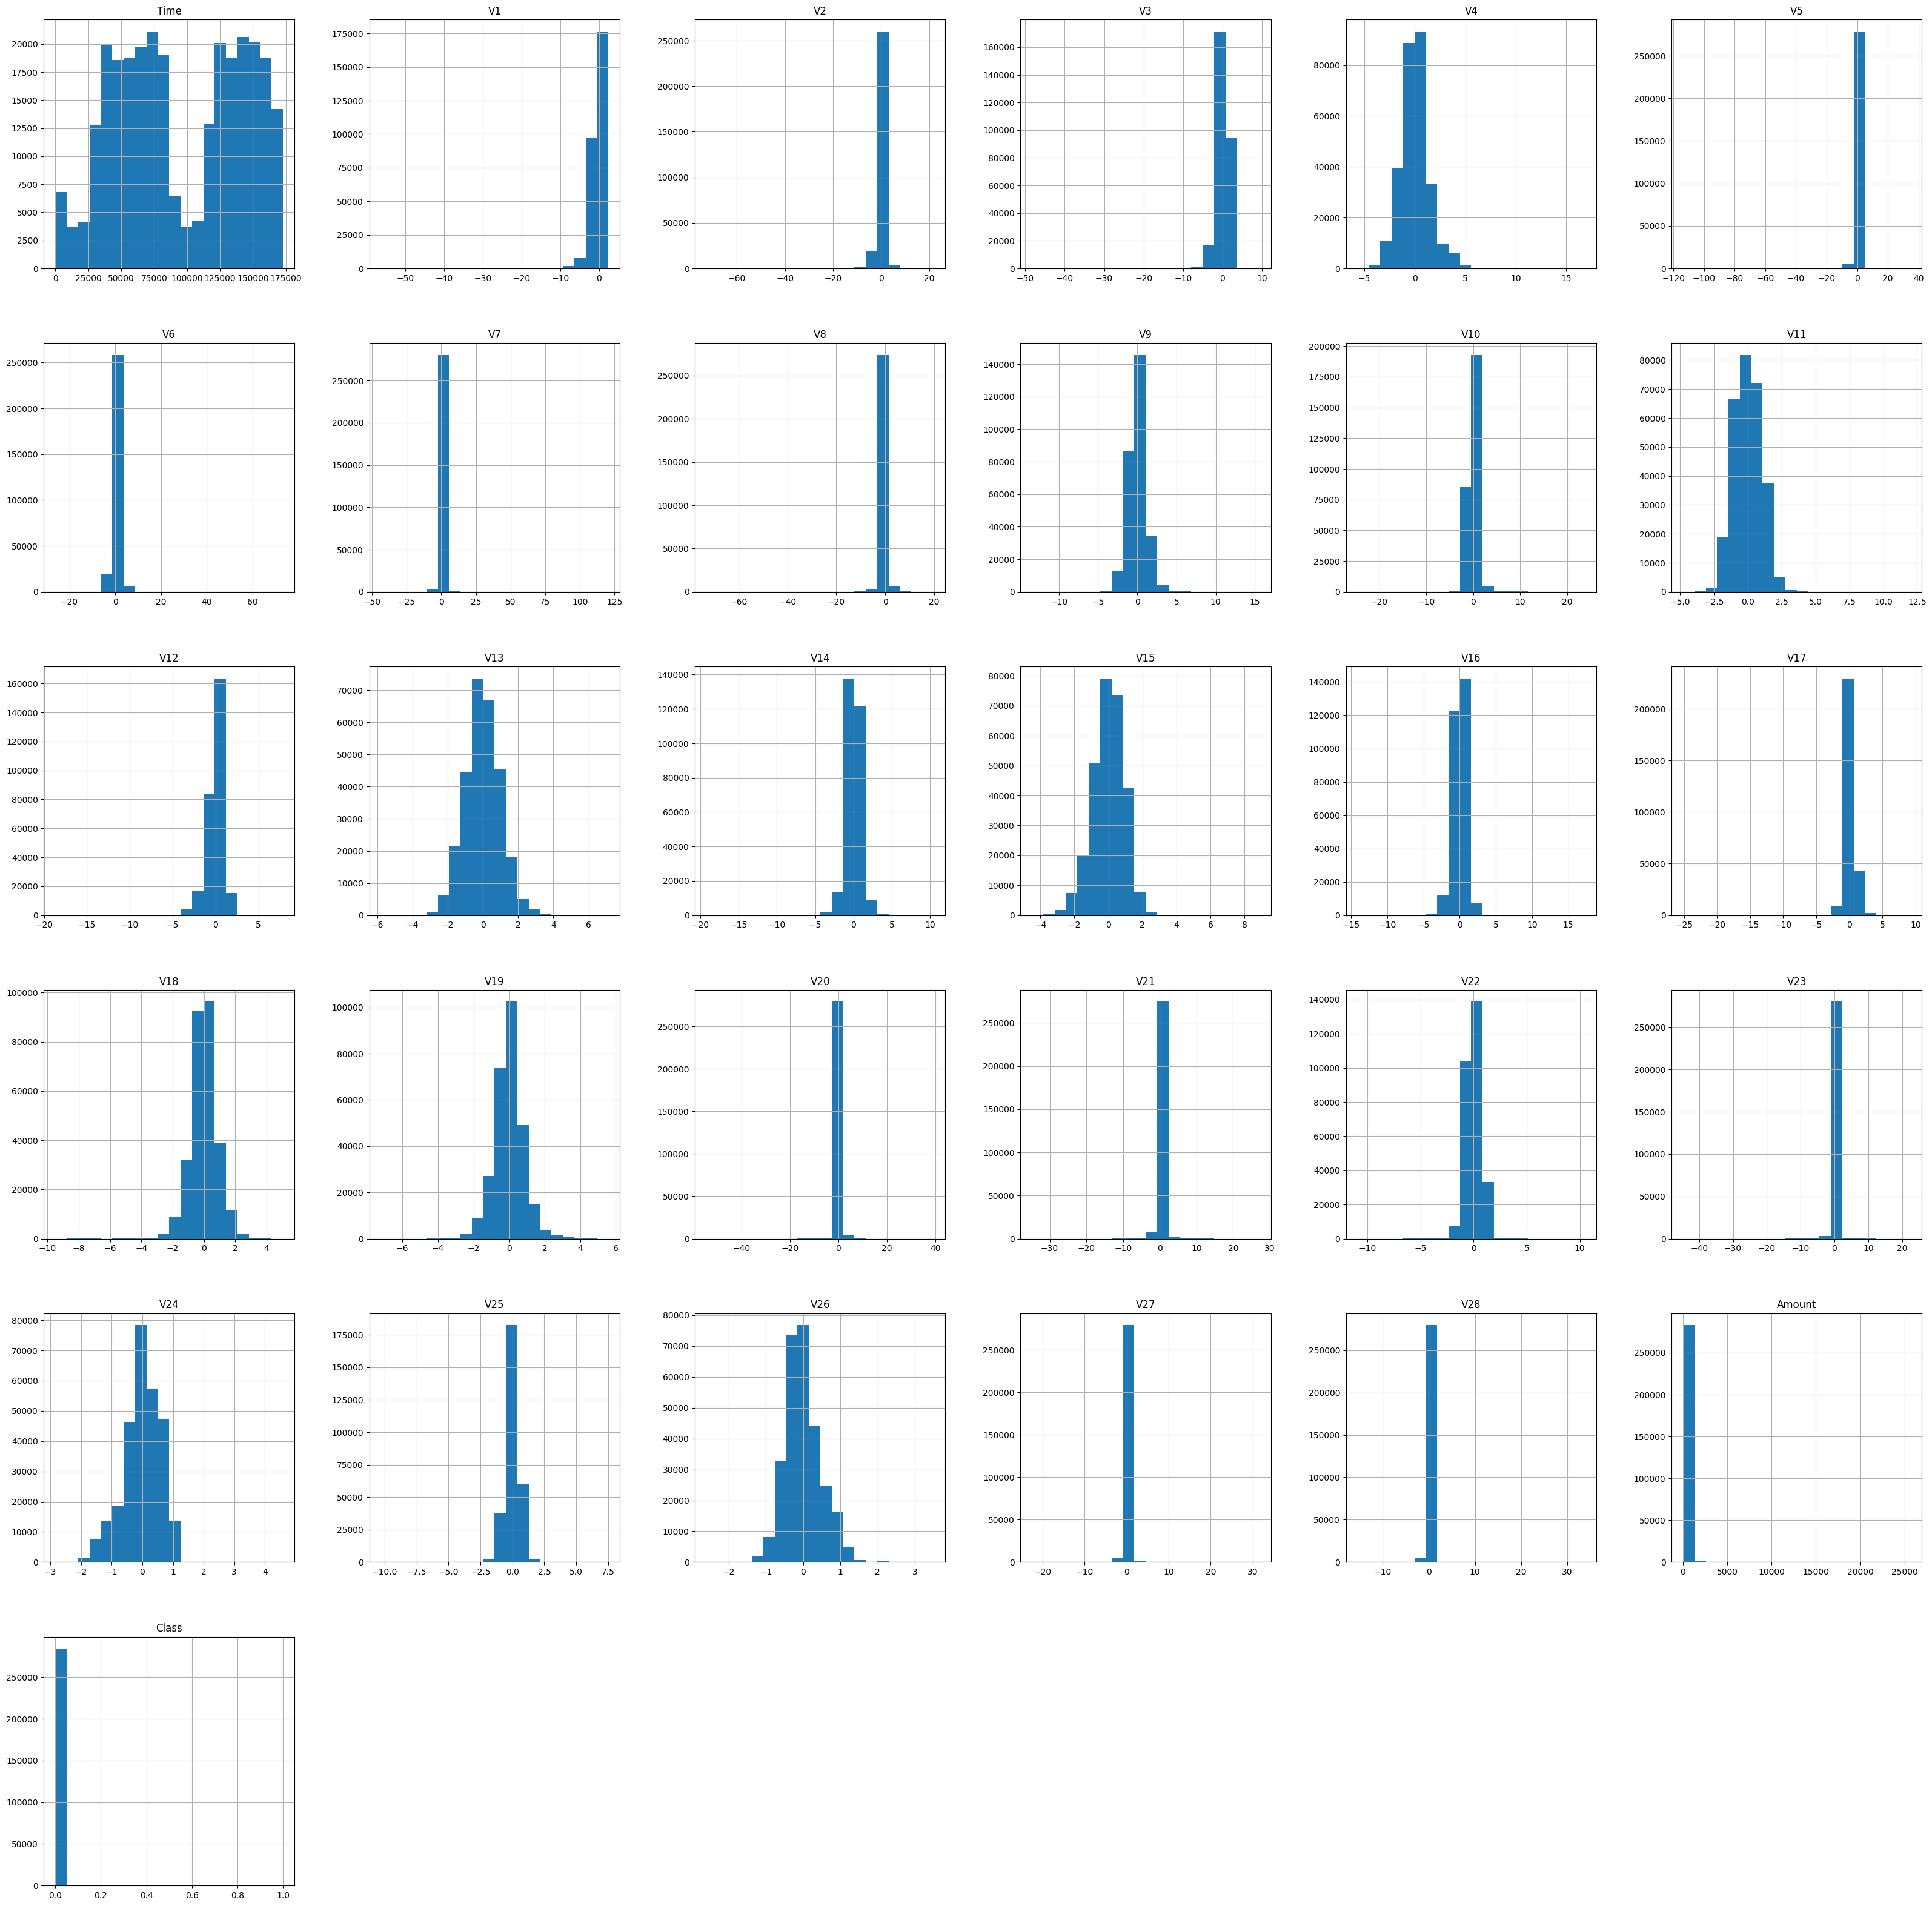

In [ ]:
df.hist(bins=20, figsize=(40, 40))

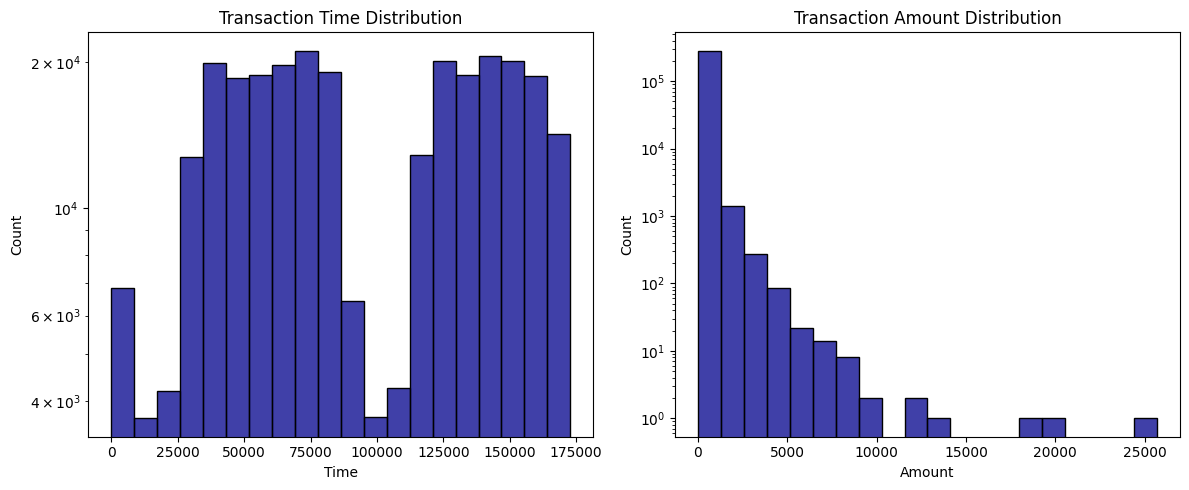

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for time
sns.histplot(df["Time"], bins=20, kde=False, color='darkblue', ax=ax[0])
ax[0].set_yscale("log")
ax[0].set_title("Transaction Time Distribution")

# Histogram for Amount
sns.histplot(df["Amount"], bins=20, kde=False, color='darkblue', ax=ax[1])
ax[1].set_yscale("log")
ax[1].set_title("Transaction Amount Distribution")

plt.tight_layout()
plt.show()


In [ ]:
df.duplicated().any() #check for duplicates

np.True_

In [ ]:
df_orgin = df.copy()
df = df.drop_duplicates()
print(df_orgin.shape[0] - df.shape[0])

1081


In [ ]:
df["Class"].value_counts()


,count
Class,
0,283253
1,473


In [ ]:
df["Class"].value_counts()/float(len(df)) * 100

,count
Class,
0,99.83329
1,0.16671


In [ ]:
df[['Amount','Time']].describe()

,Amount,Time
count,283726.000000,283726.000000
mean,88.472687,94811.077600
std,250.399437,47481.047891
min,0.000000,0.000000
25%,5.600000,54204.750000
50%,22.000000,84692.500000
75%,77.510000,139298.000000
max,25691.160000,172792.000000


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,-0.001441,0.000202,-0.000715,0.000603,0.000252,0.001043,0.001162,0.000170,0.001515,-0.000264,0.000187,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,1.076407,1.018720,0.994674,0.995430,0.952215,0.914894,0.873696,0.842507,0.837378,0.813379,0.769984,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,-4.797473,-18.683715,-5.791881,-19.214325,-4.498945,-14.129855,-25.162799,-9.498746,-7.213527,-54.497720,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,-0.535578,-0.761649,-0.406198,-0.647862,-0.425732,-0.581452,-0.466860,-0.483928,-0.498014,-0.456289,-0.211469,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,-0.093237,-0.032306,0.139072,-0.012927,0.050209,0.049299,0.067119,-0.065867,-0.002142,0.003367,-0.062353,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,0.453619,0.739579,0.616976,0.663178,0.492336,0.650104,0.523512,0.398972,0.501956,0.458508,0.133207,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,23.745136,12.018913,7.848392,7.126883,10.526766,8.877742,17.315112,9.253526,5.041069,5.591971,39.420904,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [ ]:
#copy
old = df.copy()

scaler = RobustScaler()

#scale amount & time using robust scaler
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

print(df.head())

#drop unsclaed values
df.drop(['Time','Amount'], axis=1, inplace=True)

#rename scaled vlaues
df = df.rename(columns={'scaled_amount': 'Amount', 'scaled_time':'Time', })


print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10       V11       V12       V13       V14  \
0  0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390 -0.311169   
1  0.085102 -0.255425 -0.166974  1.612727  1.065235  0.489095 -0.143772   
2  0.247676 -1.514654  0.207643  0.624501  0.066084  0.717293 -0.165946   
3  0.377436 -1.387024 -0.054952 -0.226487  0.178228  0.507757 -0.287924   
4 -0.270533  0.817739  0.753074 -0.822843  0.538196  1.345852 -1.119670   

        V15       V16       V17       V18       V19       V20 

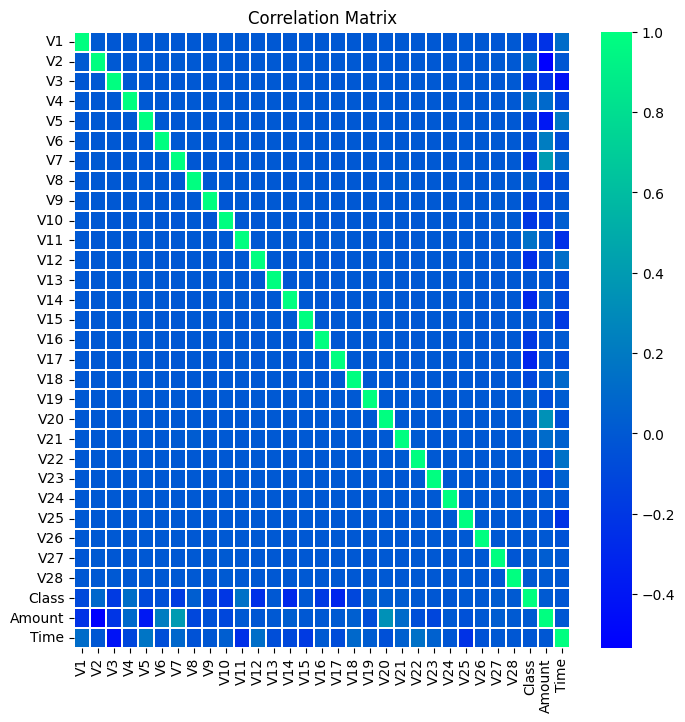

In [ ]:
plt.figure(figsize = (8,8))
plt.title("Correlation Matrix")
corr = df.corr()
sns.heatmap(corr,xticklabels=corr.columns,yticklabels=corr.columns,linewidths=.1,cmap="winter")
plt.show()

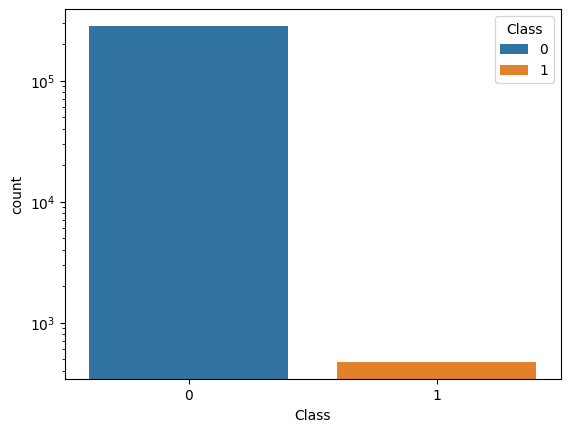

In [ ]:
an =sns.countplot(x='Class',data=df, hue='Class' );
an.set_yscale('log')

In [ ]:

# Separate fraud cases in the fata frame
df_nonfraud = df[df['Class'] == 0]
df_fraud = df[df['Class'] == 1]

# As per assigment requirement work with   (~50,000 records) for both training  & testing
sample_size = 50000 - len(df_fraud)

# random select of subset of  not fraud cases
df_down = resample(df_nonfraud, replace=False, n_samples=sample_size, random_state=42)

# Combine fraud cases with subset
df_b = pd.concat([df_down, df_fraud])

# Shuffle the dataset
df_b = df_b.sample(frac=1, random_state=42).reset_index(drop=True)

print("Class distribution:\n", df_b["Class"].value_counts())


Class distribution:
 Class
0    49527
1      473
Name: count, dtype: int64


In [ ]:
df_b["Class"].value_counts()/float(len(df_b)) * 100

,count
Class,
0,99.054
1,0.946


In [ ]:
X = df_b.drop("Class", axis=1)
y = df_b["Class"]

# Stratified split to maintain fraud ratio
x_train, x_test, y_train, y_test = train_test_split( X, y, test_size=0.25, stratify=y, random_state=42 )

In [ ]:
len(y_train)

37500

In [ ]:


#ratio = 1 / 2
#ros = RandomOverSampler(sampling_strategy=ratio, random_state=42)
#x_train_ros, y_train_ros = ros.fit_resample(x_train, y_train)

# initialise SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)
#apply smote to training datat
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print("Before oversampling:", y_train.value_counts())
print("After oversampling:", y_train_smote.value_counts())


Before oversampling: Class
0    37145
1      355
Name: count, dtype: int64
After oversampling: Class
0    37145
1    37145
Name: count, dtype: int64


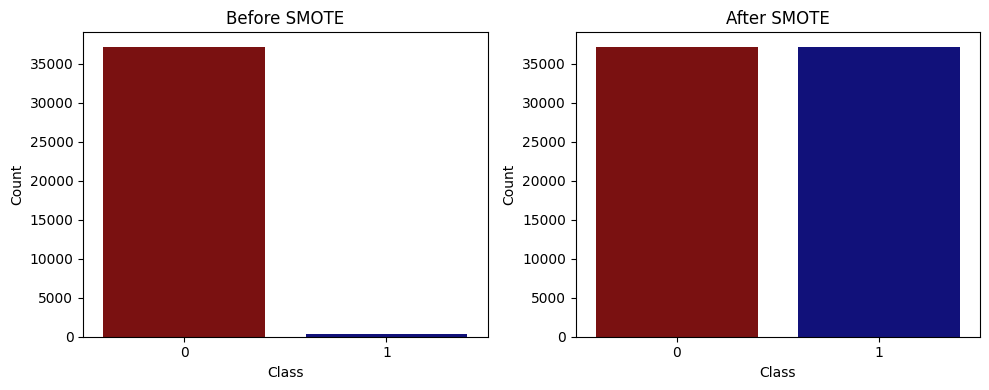

In [ ]:

plt.figure(figsize=(10, 4))

# Before SMOTE
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, hue=y_train, palette={0: "darkred", 1: "darkblue"}, legend=False)
plt.title("Before SMOTE")
plt.xlabel('Class')
plt.ylabel('Count')

# After SMOTE
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote, hue=y_train_smote, palette={0: "darkred", 1: "darkblue"}, legend=False)
plt.title("After SMOTE")
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


## Model Implementation

### Model

### LogisticRegression

In [ ]:
lr_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    max_iter=1000,
    random_state=42
)

lr_model.fit(x_train_smote,  y_train_smote)



LogisticRegression(max_iter=1000, random_state=42)

#### Coefficient Analysis

In [ ]:
lr_coef = pd.DataFrame({'Feature': lr_model.feature_names_in_,'Coefficients': lr_model.coef_[0]}).set_index('Feature')
lr_coef=lr_coef.sort_values(by='Coefficients')

In [ ]:
lr_coef

,Coefficients
Feature,
V14,-1.487646
V20,-1.233888
V12,-1.016456
V7,-0.876571
V17,-0.822813
V6,-0.785353
V16,-0.637576
V26,-0.618934
Time,-0.610936


Text(0.5, 1.0, 'Regression Coefficients')

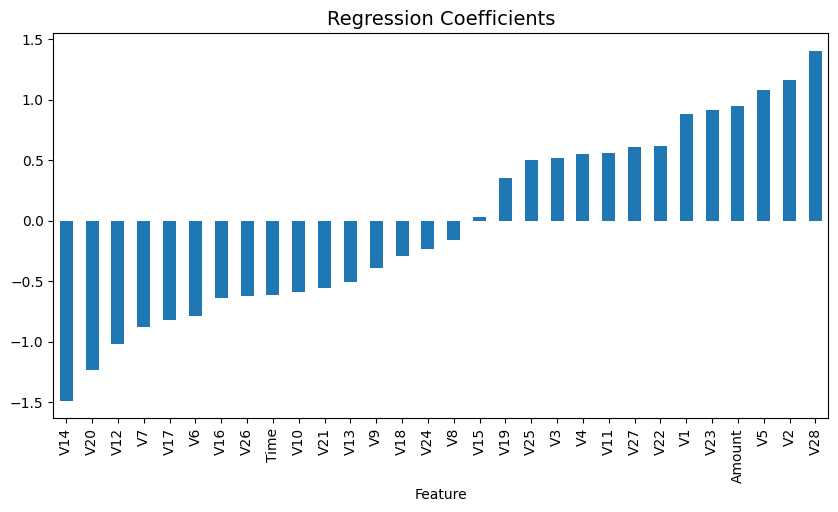

In [ ]:

lr_coef["Coefficients"].plot.bar(figsize=(10,5))
plt.title("Regression Coefficients",fontsize=14)

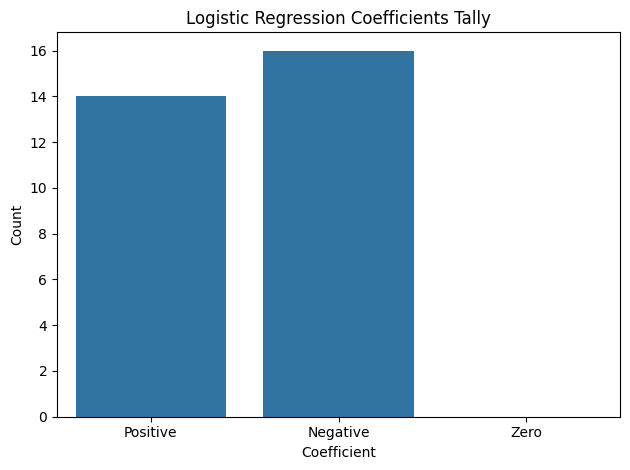

In [ ]:
lr_coef["Sign"] = np.sign(lr_coef["Coefficients"]).map({1: "Positive", -1: "Negative", 0: "Zero"})

# Countplot
ax = sns.countplot(data=lr_coef, x="Sign", order=["Positive", "Negative", "Zero"])
ax.set_title("Logistic Regression Coefficients Tally")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Count")



plt.tight_layout()
plt.show()

In [ ]:
lr_model.intercept_[0]

np.float64(-4.331376878045326)

### Support Vector Machine (SVM)

In [ ]:
# Pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=True, cache_size=1000, random_state=42))
])

# parameter search
param_dist = {
    "svc__kernel": ["rbf", "linear", "poly"],
    "svc__C": loguniform(1e-1, 1e2),
    "svc__gamma": loguniform(1e-3, 1e1)
}

# configs for ranodom search
hrs = HalvingRandomSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_candidates=10,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

# Fit model
hrs.fit(x_train_smote, y_train_smote)

print("Best parameters:", hrs.best_params_)
print("Best CV ROC-AUC:", hrs.best_score_)

# save best params
svm_model = hrs.best_estimator_
y_pred = svm_model.predict(x_test)
y_score = svm_model.decision_function(x_test)



n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 8
min_resources_: 12
max_resources_: 74290
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 10
n_resources: 12
Fitting 3 folds for each of 10 candidates, totalling 30 fits
----------
iter: 1
n_candidates: 4
n_resources: 36
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 2
n_candidates: 2
n_resources: 108
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best parameters: {'svc__C': np.float64(7.119418600172988), 'svc__gamma': np.float64(0.27964859516062457), 'svc__kernel': 'rbf'}
Best CV ROC-AUC: 0.9296600877192982


###  Random Forest Classifier


In [ ]:
#random forest mdoel
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

#train model
rf_model.fit(x_train_smote, y_train_smote)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

#### Feature importance

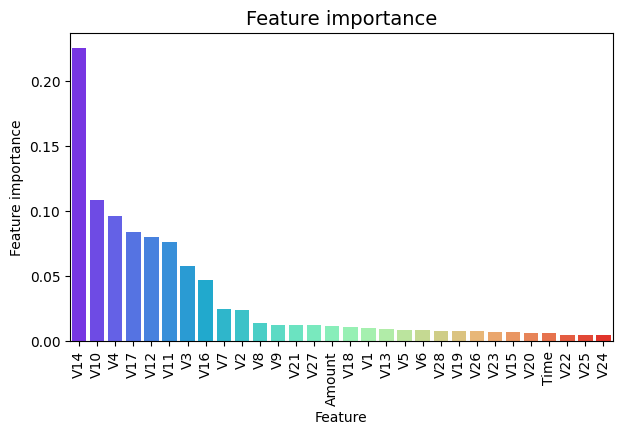

In [ ]:
#Df for featur importance and their names
rf_fI = pd.DataFrame({'Feature': lr_model.feature_names_in_,'Feature importance': rf_model.feature_importances_}).set_index('Feature').sort_values(by='Feature importance',ascending=False)

#create bar plot
plt.figure(figsize = (7,4))
plt.title('Feature importance',fontsize=14)
sns.barplot(x='Feature',y='Feature importance',data=rf_fI,palette="rainbow" , hue='Feature' )
plt.xticks(rotation=90)
plt.show()

In [ ]:
rf_fI

,Feature importance
Feature,
V14,0.225594
V10,0.108514
V4,0.096107
V17,0.084185
V12,0.080045
V11,0.076642
V3,0.058123
V16,0.047020
V7,0.024502


### Neural Network

In [ ]:
#Neural Network Structure
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train_smote.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the Model
nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name='auc')]
)

#stopping early help prevent overfitting
early_stop = EarlyStopping(
    monitor="auc",
    patience=2,
    restore_best_weights=True
)

#Train model
history = nn_model.fit(
    x_train_smote, y_train_smote,
    epochs=100,
    batch_size=256,
    verbose=1,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8239 - auc: 0.8988 - loss: 0.3735
Epoch 2/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9614 - auc: 0.9940 - loss: 0.0996
Epoch 3/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9727 - auc: 0.9970 - loss: 0.0717
Epoch 4/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9806 - auc: 0.9982 - loss: 0.0547
Epoch 5/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9852 - auc: 0.9987 - loss: 0.0434
Epoch 6/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9890 - auc: 0.9990 - loss: 0.0346
Epoch 7/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9909 - auc: 0.9994 - loss: 0.0275
Epoch 8/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9937 - auc: 0.9994 - loss: 0.0227
Epoch 9/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9949 - auc: 0.9995 - loss: 0.0187
Epoch 10/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9954 - auc: 0.9996 - l

In [ ]:
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,293 (48.02 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,196 (32.02 KB)

## Models Evaluation

In [ ]:
def eval_m(y_pred, model_name, y_score):
    """
        prints  a summary table, confusion-matrix , and ROC plot for a specified model
    """


    #metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_score)

    #score summary

    summary = pd.DataFrame([{"Model": model_name, "Accuracy": acc,"Precision": prec,"Recall": rec,"F1-Score": f1, "AUC-ROC": auc }]).set_index("Model").round(4)

    #printouts

    print(f"\t\t{model_name}\n")
    print(summary)
    print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(pd.DataFrame(cm,columns=["Predicted:0","Predicted:1"],index=["Actual:0","Actual:1"]),annot=True, fmt='d', cmap="YlGnBu")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    #roc curve
    fpr, tpr, th = roc_curve(y_test, y_score)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.2f})", linewidth=2)
    plt.plot([0,1], [0,1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}")

    plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

    print("\n\n\n\n")

		Logistic Regression

                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.9756     0.2633  0.8814    0.4055   0.9728

Classification Report:
               precision    recall  f1-score   support

           0     0.9988    0.9765    0.9875     12382
           1     0.2633    0.8814    0.4055       118

    accuracy                         0.9756     12500
   macro avg     0.6311    0.9289    0.6965     12500
weighted avg     0.9919    0.9756    0.9820     12500



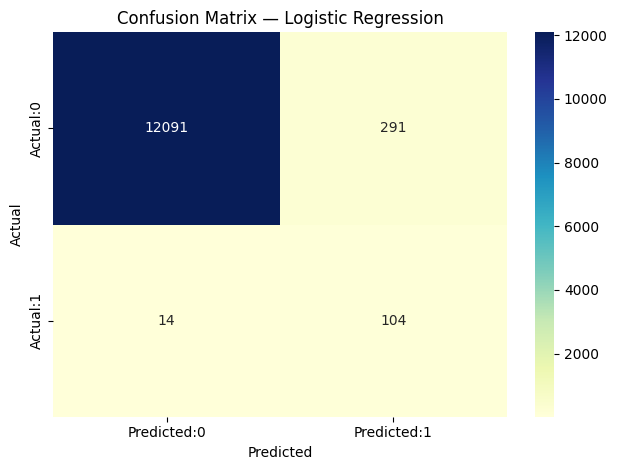

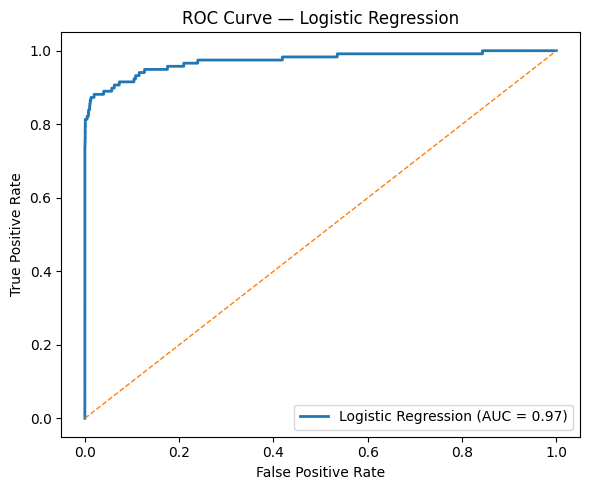






		SVM

       Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                
SVM      0.9933     0.7361  0.4492    0.5579   0.9489

Classification Report:
               precision    recall  f1-score   support

           0     0.9948    0.9985    0.9966     12382
           1     0.7361    0.4492    0.5579       118

    accuracy                         0.9933     12500
   macro avg     0.8654    0.7238    0.7773     12500
weighted avg     0.9923    0.9933    0.9925     12500



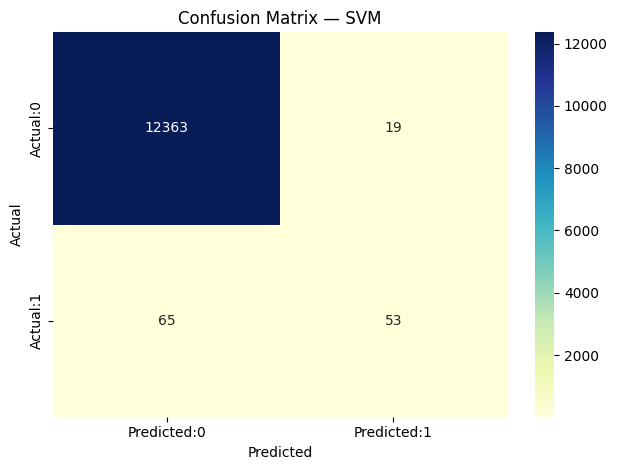

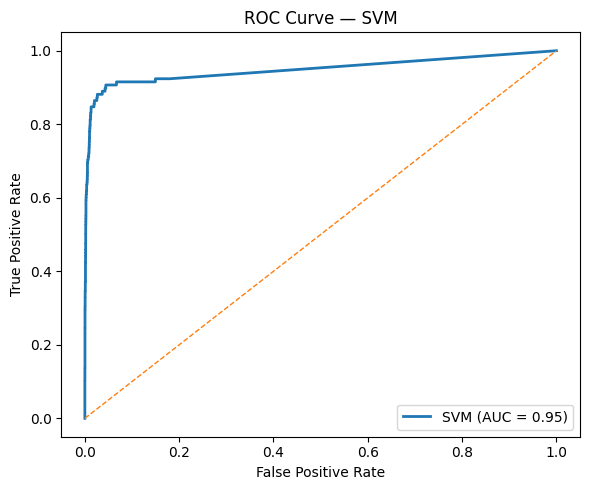






		Random Forest

               Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                        
Random Forest    0.9976     0.9314  0.8051    0.8636   0.9854

Classification Report:
               precision    recall  f1-score   support

           0     0.9981    0.9994    0.9988     12382
           1     0.9314    0.8051    0.8636       118

    accuracy                         0.9976     12500
   macro avg     0.9648    0.9023    0.9312     12500
weighted avg     0.9975    0.9976    0.9975     12500



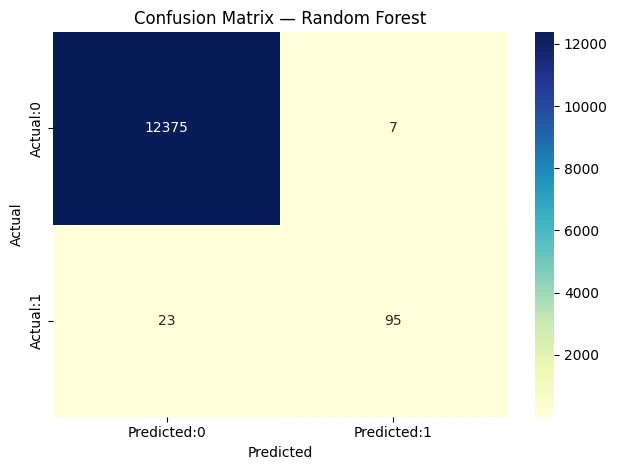

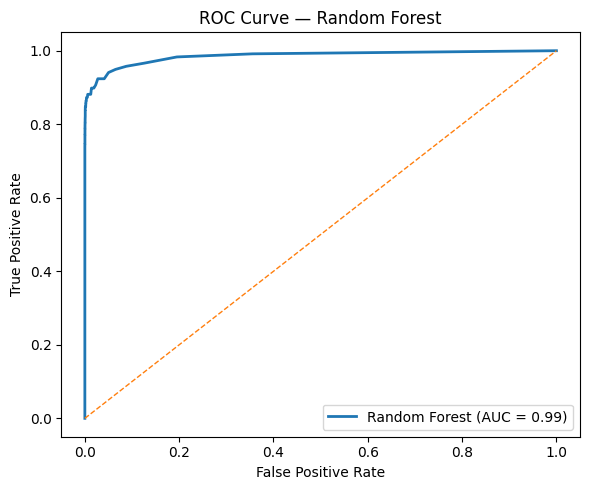






		Neural Network

                Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                         
Neural Network    0.9957     0.7424  0.8305     0.784   0.9518

Classification Report:
               precision    recall  f1-score   support

           0     0.9984    0.9973    0.9978     12382
           1     0.7424    0.8305    0.7840       118

    accuracy                         0.9957     12500
   macro avg     0.8704    0.9139    0.8909     12500
weighted avg     0.9960    0.9957    0.9958     12500



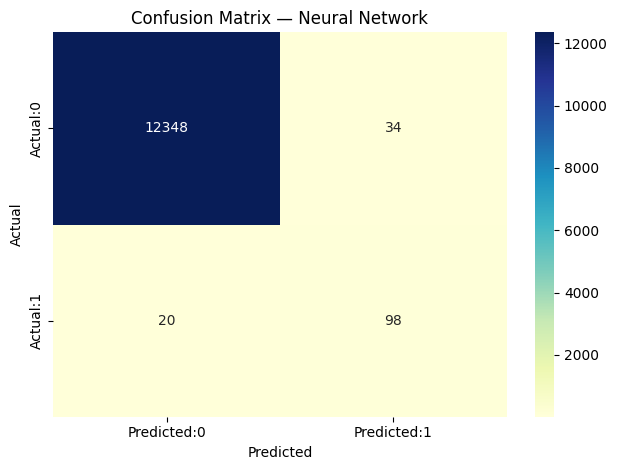

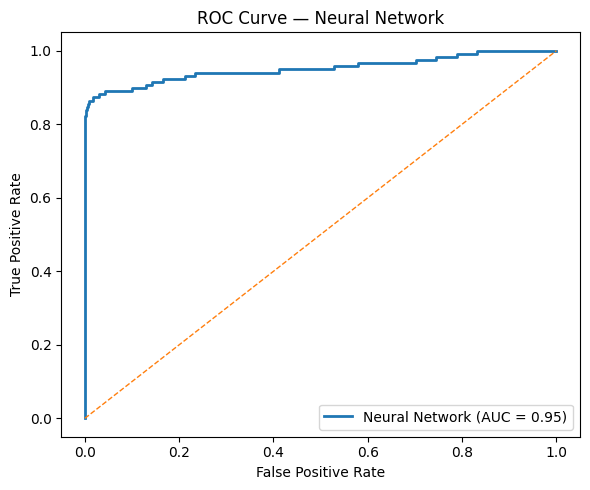

In [ ]:
# logistic Regression
eval_m(lr_model.predict(x_test),"Logistic Regression", y_score=lr_model.predict_proba(x_test)[:, 1])

# SVM model
eval_m(svm_model.predict(x_test), "SVM",  y_score=svm_model.predict_proba(x_test)[:, 1])

# Random Forest
eval_m(rf_model.predict(x_test), "Random Forest",  y_score=rf_model.predict_proba(x_test)[:, 1])

# Neural Network
nn_probs = nn_model.predict(x_test, verbose=0).ravel()
eval_m((nn_probs >= 0.5).astype(int),"Neural Network",   y_score=nn_probs)

## Results

### ROC curve

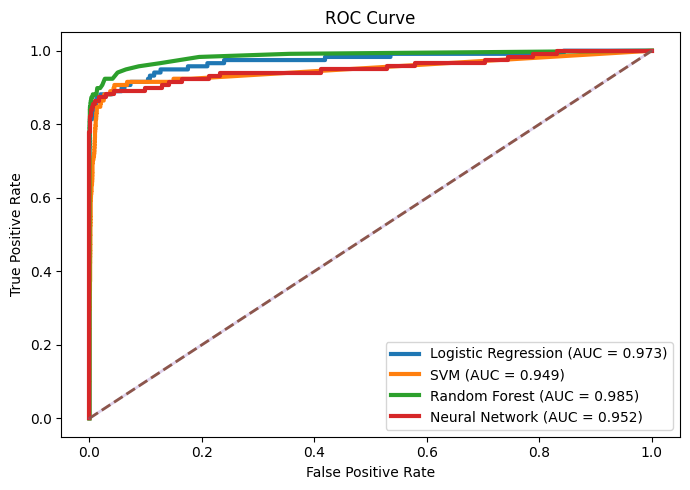

In [ ]:


models = [
    ("Logistic Regression", lr_model, lr_model.predict_proba(x_test)[:, 1]),
    ("SVM", svm_model, svm_model.predict_proba(x_test)[:, 1]),
    ("Random Forest", rf_model , rf_model.predict_proba(x_test)[:, 1]),
    ("Neural Network", nn_model, nn_model.predict(x_test, verbose=0).ravel()),
]

#plot ROC curves for each model
plt.figure(figsize=(7,5))
for name, mdl , y_prob in models:
    fpr, tpr, th = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=3)

plt.plot([0,1], [0,1] ,linewidth=2, alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.plot([0,1], [0,1], linestyle="dashed", linewidth=2)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:

# combine all metrics in one table
rows = []
for name, mdl, y_prob in models:
    if name == "Neural Network":
        y_pred = (y_prob > 0.5).astype(int)
    else:
        y_pred = mdl.predict(x_test)

    rows.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred, zero_division=0),
        "AUC-ROC":   roc_auc_score(y_test, y_prob),
    })

metrics_df = pd.DataFrame(rows).set_index("Model").round(3)


### Table

In [ ]:
metrics_df #sumamry of model performance

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.976,0.263,0.881,0.405,0.973
SVM,0.993,0.736,0.449,0.558,0.949
Random Forest,0.998,0.931,0.805,0.864,0.985
Neural Network,0.996,0.742,0.831,0.784,0.952


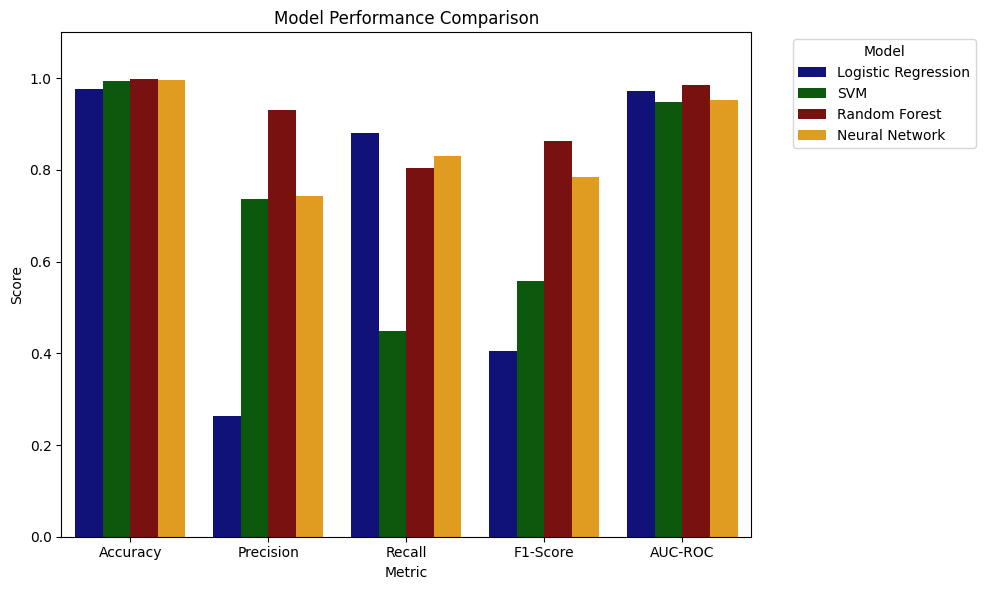

In [ ]:
# Melt the Df to long format
plot_df = metrics_df.reset_index().melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"],var_name="Metric",value_name="Score")

# Plot all metrics in one graph
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette={"darkred", "darkblue", "darkgreen","orange"})

ax.set_ylim(0, 1.1)
ax.set_title("Model Performance Comparison")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
